# Fraud Detection System - Phase 2

This notebook covers Person A responsibilities:

- Exploratory Data Analysis (EDA)
- Baseline models
- Baseline metrics
- Problem identification

Baseline models implemented:
1. Logistic Regression
2. Decision Tree
3. Random Forest


## 1) Download Dataset

Purpose: Ensure the Credit Card Fraud Detection dataset is available locally.


In [1]:
import os
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
file_name = "creditcard.csv"

if not os.path.exists(file_name):
    response = requests.get(url)
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("Downloaded")
else:
    print("Already exists")


Downloaded


## 2) Imports

Purpose: Load all required libraries.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


## 3) Load Data

Purpose: Read the dataset and preview the first rows.


In [3]:
df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4) Exploratory Data Analysis (EDA)

Purpose: Understand the dataset structure, class distribution, and feature relationships.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df['Class'].value_counts()


,count
Class,
0,284315
1,492


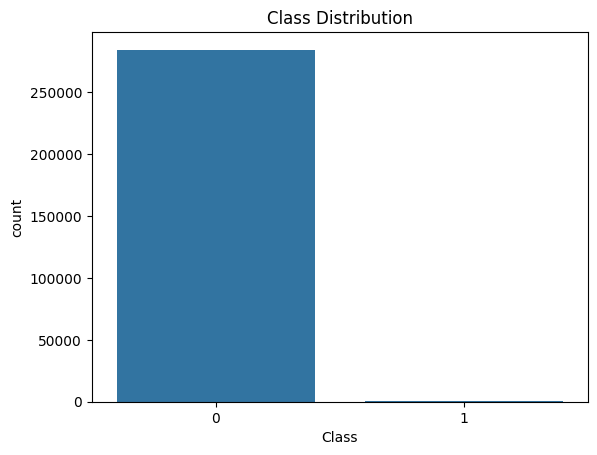

In [7]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()


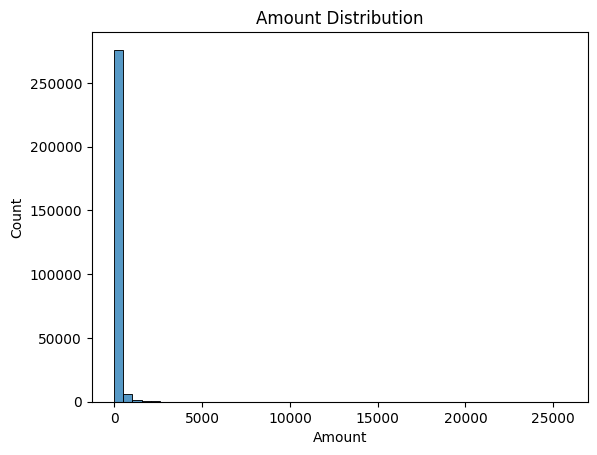

In [8]:
sns.histplot(df['Amount'], bins=50)
plt.title("Amount Distribution")
plt.show()


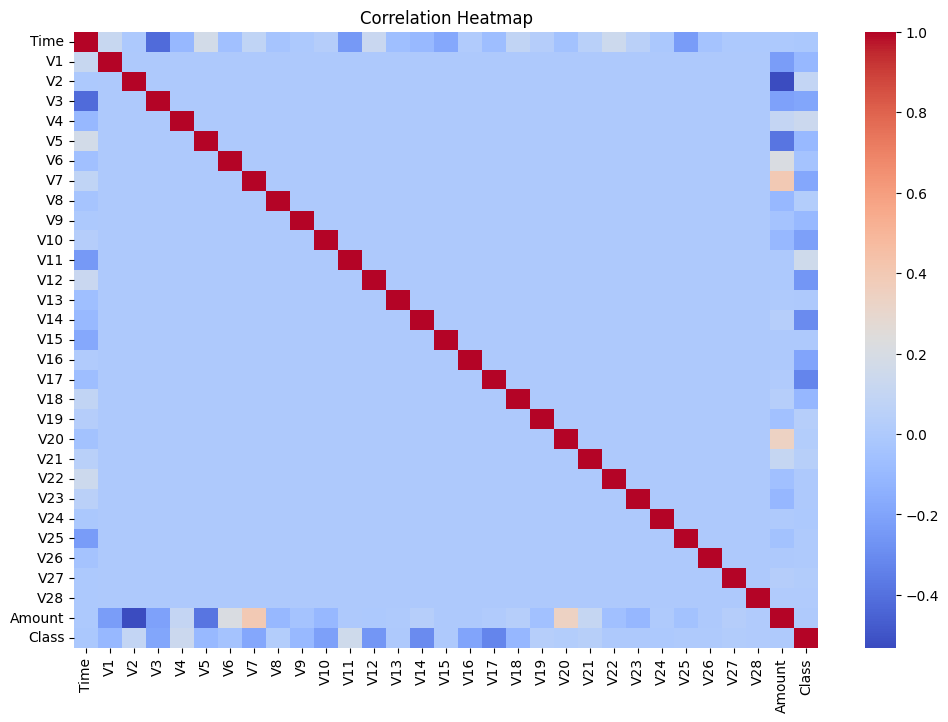

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## 5) Data Preprocessing

Purpose: Split the data into training and testing sets, then scale numerical features.


In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6) Helper Function for Evaluation

Purpose: Avoid repeating metric calculations for each model.


In [11]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"{model_name} Results")
    print("-" * 40)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }


## 7) Baseline Model 1: Logistic Regression

Purpose: Train a simple interpretable baseline model.


Logistic Regression Results
----------------------------------------
Accuracy: 0.9755275446789088
Precision: 0.06097560975609756
Recall: 0.9183673469387755
F1-score: 0.11435832274459974
ROC-AUC: 0.9720834996210077

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



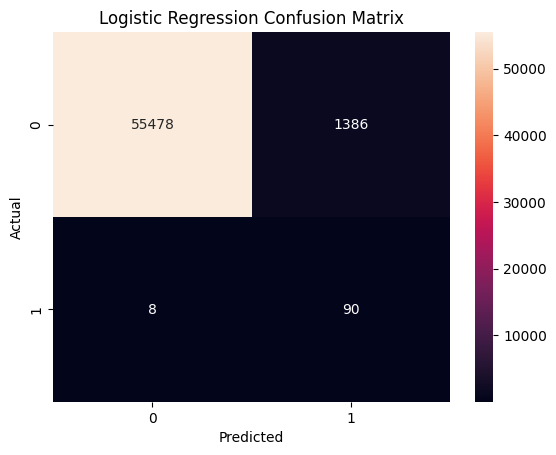

In [12]:
LR_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
LR_model.fit(X_train_scaled, y_train)

LR_pred = LR_model.predict(X_test_scaled)
LR_prob = LR_model.predict_proba(X_test_scaled)[:, 1]

LR_results = evaluate_model("Logistic Regression", y_test, LR_pred, LR_prob)


## 8) Baseline Model 2: Decision Tree

Purpose: Train a tree-based model that can capture non-linear patterns.


Decision Tree Results
----------------------------------------
Accuracy: 0.9989291106351603
Precision: 0.6761904761904762
Recall: 0.7244897959183674
F1-score: 0.6995073891625616
ROC-AUC: 0.8619459390396564

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.72      0.70        98

    accuracy                           1.00     56962
   macro avg       0.84      0.86      0.85     56962
weighted avg       1.00      1.00      1.00     56962



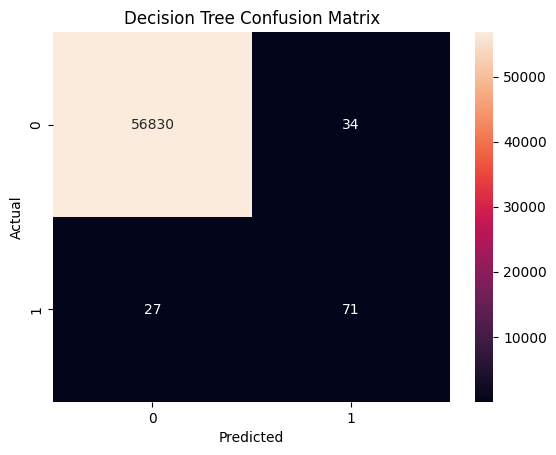

In [13]:
DT_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
DT_model.fit(X_train_scaled, y_train)

DT_pred = DT_model.predict(X_test_scaled)
DT_prob = DT_model.predict_proba(X_test_scaled)[:, 1]

DT_results = evaluate_model("Decision Tree", y_test, DT_pred, DT_prob)


## 9) Baseline Model 3: Random Forest

Purpose: Train an ensemble baseline model that usually performs better than a single decision tree.


Random Forest Results
----------------------------------------
Accuracy: 0.9995084442259752
Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1-score: 0.8390804597701149
ROC-AUC: 0.9529050875414883

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



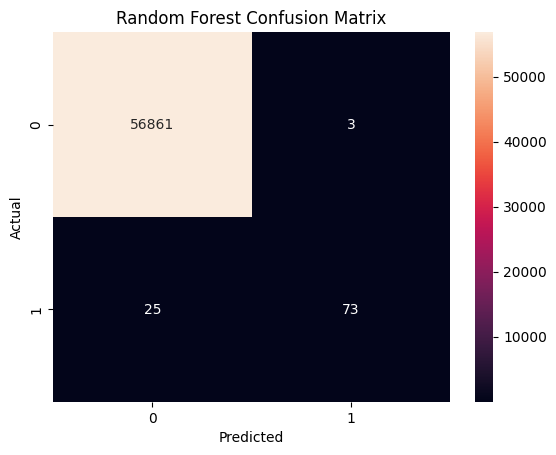

In [14]:
RF_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

RF_model.fit(X_train_scaled, y_train)

RF_pred = RF_model.predict(X_test_scaled)
RF_prob = RF_model.predict_proba(X_test_scaled)[:, 1]

RF_results = evaluate_model("Random Forest", y_test, RF_pred, RF_prob)


## 10) Baseline Models Comparison

Purpose: Compare all baseline models using the required evaluation metrics.


In [15]:
results = pd.DataFrame([LR_results, DT_results, RF_results])
results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972083
1,Decision Tree,0.998929,0.676190,0.724490,0.699507,0.861946
2,Random Forest,0.999508,0.960526,0.744898,0.839080,0.952905


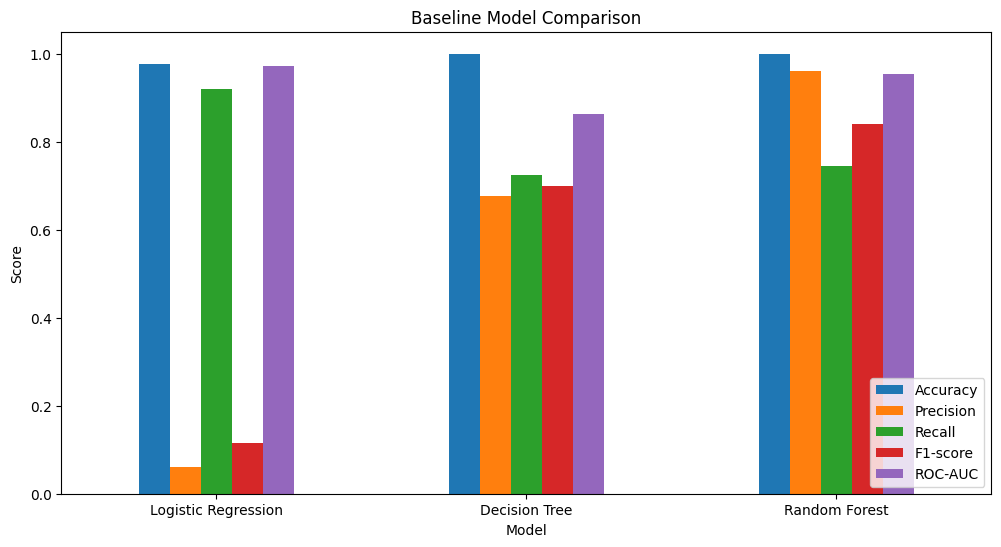

In [16]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


## 11) Problem Identification

Main problems identified in this fraud detection task:

- The dataset is highly imbalanced.
- Fraud cases are very rare compared to legitimate transactions.
- Accuracy alone can be misleading.
- Recall and F1-score are more useful than accuracy for this problem.
- A model with high accuracy may still fail to detect many fraud cases.
- More advanced models, such as DNNs, should be compared against these baselines.


## 12) Conclusion

Three baseline models were implemented: Logistic Regression, Decision Tree, and Random Forest.

Logistic Regression provides a simple and interpretable baseline. Decision Tree can capture non-linear relationships but may overfit. Random Forest is usually more stable because it combines multiple decision trees.

Because the dataset is imbalanced, Recall, F1-score, and ROC-AUC are more important than Accuracy. These baseline results can later be compared with the deep learning model.
